Importing Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Churn.xlsx to Churn.xlsx


Customer Churn excel sheet
(using pandaa library)

In [ ]:
df = pd.read_excel('Churn.xlsx')

In [ ]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
df.columns.shape

(14,)

Selecting important features

In [ ]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

converting string to integer

In [ ]:
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
display(df.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
df['Geography']  = df['Geography'].map({'France': 0, 'Germany': 1, 'Spain': 2})

In [ ]:
df.duplicated().value_counts()

,count
False,10000


Selecting X and Y

In [ ]:
x = df.iloc[:,1:-1]

In [ ]:
x

,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,0,0,42,2,0.00,1,1,1,101348.88
1,2,0,41,1,83807.86,1,0,1,112542.58
2,0,0,42,8,159660.80,3,1,0,113931.57
3,0,0,39,1,0.00,2,0,0,93826.63
4,2,0,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...
9995,0,1,39,5,0.00,2,1,0,96270.64
9996,0,1,35,10,57369.61,1,1,1,101699.77
9997,0,0,36,7,0.00,1,0,1,42085.58
9998,1,1,42,3,75075.31,2,1,0,92888.52


In [ ]:
y = df.iloc[:,-1]

In [ ]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


Spliting the data from training and testing int 80:20 ratio

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [ ]:
x_train.shape

(8000, 9)

In [ ]:
x_test.shape

(2000, 9)

In [ ]:
y_test.shape

(2000,)

In [ ]:
y_train.shape

(8000,)

In [ ]:
from sklearn.preprocessing import StandardScaler

Applying standard scaler for normalising the data

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


display(x_train_scaled[:5])
display(x_test_scaled[:5])

array([[ 1.51919821, -1.09168714, -0.46460796,  0.00666099, -1.21571749,
         0.8095029 ,  0.64259497, -1.03227043,  1.10643166],
       [ 0.3131264 ,  0.91601335,  0.30102557, -1.37744033, -0.00631193,
        -0.92159124,  0.64259497,  0.9687384 , -0.74866447],
       [-0.89294542, -1.09168714, -0.94312892, -1.031415  ,  0.57993469,
        -0.92159124,  0.64259497, -1.03227043,  1.48533467],
       [ 1.51919821,  0.91601335,  0.10961719,  0.00666099,  0.47312769,
        -0.92159124,  0.64259497, -1.03227043,  1.27652776],
       [ 1.51919821, -1.09168714,  1.73658844,  1.04473698,  0.8101927 ,
         0.8095029 ,  0.64259497,  0.9687384 ,  0.55837842]])

array([[ 0.3131264 , -1.09168714, -0.36890377,  1.04473698,  0.8793029 ,
        -0.92159124,  0.64259497,  0.9687384 ,  1.61085707],
       [-0.89294542, -1.09168714,  0.10961719, -1.031415  ,  0.42972196,
        -0.92159124,  0.64259497, -1.03227043,  0.49587037],
       [ 1.51919821, -1.09168714,  0.30102557,  1.04473698,  0.30858264,
        -0.92159124,  0.64259497,  0.9687384 , -0.42478674],
       [-0.89294542,  0.91601335, -0.65601634, -0.33936434,  0.57533623,
        -0.92159124, -1.55619021, -1.03227043, -0.18777657],
       [ 0.3131264 ,  0.91601335, -0.08179119,  0.00666099,  1.38961097,
         0.8095029 ,  0.64259497,  0.9687384 ,  0.61684179]])

Importing Libraries from tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()

Creating Deep Learning model where we use relu activation function for hidden layer and getting output in 0 or 1 using sigmoid activation function

In [ ]:
model.add(Dense(32,activation='relu',input_dim=9))
model.add(Dense(16,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(4,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Getting model summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

Compiling the model uing adam optimizer and calculating loss fucntion using BCE

In [ ]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

we use epoch for iteration

In [ ]:
history = model.fit(x_train_scaled,y_train,batch_size=32,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6463 - loss: 0.6601 - val_accuracy: 0.7994 - val_loss: 0.4613
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8096 - loss: 0.4361 - val_accuracy: 0.8294 - val_loss: 0.3953
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8420 - loss: 0.3786 - val_accuracy: 0.8406 - val_loss: 0.3855
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8589 - loss: 0.3542 - val_accuracy: 0.8413 - val_loss: 0.3779
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8447 - loss: 0.3673 - val_accuracy: 0.8469 - val_loss: 0.3733
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8530 - loss: 0.3539 - val_accuracy: 0.8462 - val_loss: 0.3752
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8613 - loss: 0.3404 - val_accuracy: 0.8469 - val_loss: 0.3678
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8663 - loss: 0.3278 - val_accu

In [ ]:
from sklearn.metrics import accuracy_score

predicting the model

In [ ]:
y_pred = model.predict(x_test_scaled )
y_pred

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.16877282],
       [0.07993824],
       [0.0653436 ],
       ...,
       [0.06982924],
       [0.46265736],
       [0.09936619]], dtype=float32)

In [ ]:
if (y_pred == False).all():
    print(" Not Exited")
else:
    print("Exited")

Exited


Visualize


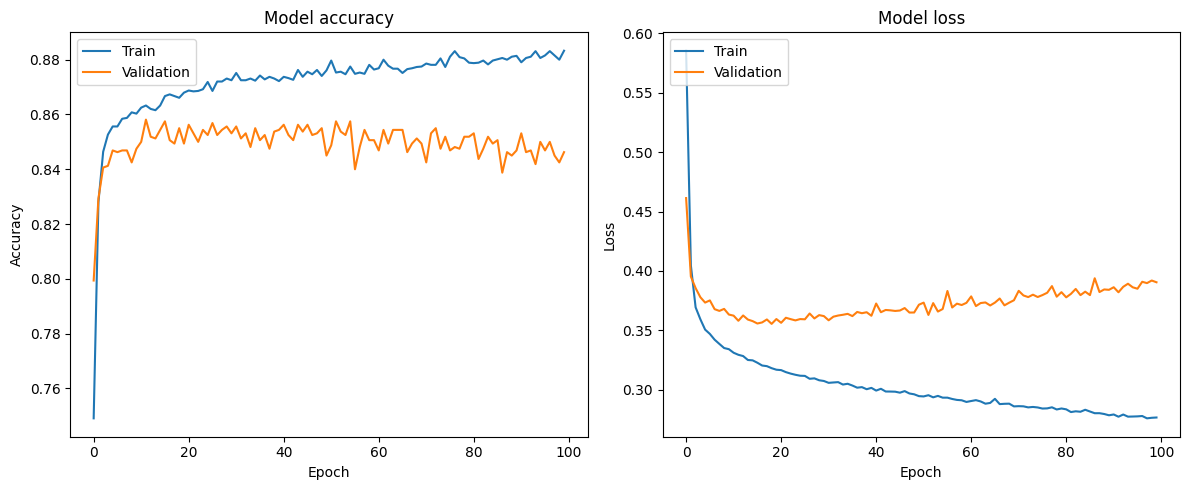

In [ ]:
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
accuracy_score(y_test,y_pred.round())

0.8455

In [ ]:
from sklearn.metrics import confusion_matrix


Performance Matrices


In [ ]:
confusion_matrix(y_test,y_pred.round())

array([[1496,   99],
       [ 210,  195]])

<Axes: >

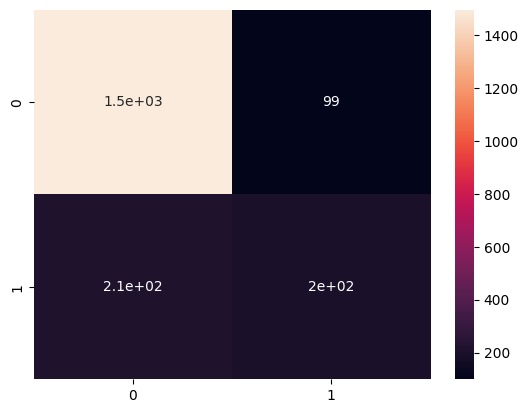

In [ ]:

sns.heatmap(confusion_matrix(y_test,y_pred.round()),annot=True)


In [ ]:
display(y_pred.round()[:10])

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.]], dtype=float32)

Here's a summary count of predicted exited (1) and not exited (0) customers in the test set.

In [ ]:
unique, counts = np.unique(y_pred.round(), return_counts=True)
prediction_counts = dict(zip(unique, counts))
print(f"Predicted Not Exited (0): {prediction_counts.get(0.0, 0)}")
print(f"Predicted Exited (1): {prediction_counts.get(1.0, 0)}")

Predicted Not Exited (0): 1706
Predicted Exited (1): 294


In [ ]:
unique, counts = np.unique(y_test.round(), return_counts=True)
prediction_counts = dict(zip(unique, counts))
print(f"Predicted Not Exited (0): {prediction_counts.get(0.0, 0)}")
print(f"Predicted Exited (1): {prediction_counts.get(1.0, 0)}")

Predicted Not Exited (0): 1595
Predicted Exited (1): 405


In [ ]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.flatten()
})

print(results.head(10))

   Actual  Predicted
0       0   0.168773
1       1   0.079938
2       0   0.065344
3       0   0.032311
4       0   0.041653
5       1   0.950614
6       0   0.224749
7       0   0.064167
8       1   0.012246
9       1   0.748307
